# T2 - Population clipping
This example shows up to calculate populations contained within a shapefile using a population raster (e.g., WorldPop)

In [1]:
import rastertoolkit
from importlib.metadata import version

from rastertoolkit import raster_clip
from rastertoolkit.shape import plot_shapes

print(f"rastertoolkit version v{version("rastertoolkit")}\n")

rastertoolkit version v0.5.1



We need both a raster file with the population data along with the shapes.

In [2]:
# Using example DRC shapefile and raster
shape_file = "data/COD_LEV02_ZONES"
raster_file = "data/cod_2020_1km_aggregated_unadj.tif"

Now we clip. Note that we'll use one of the fieldnames (default: DOTNAME) that is contained in the shapefile to provide an index for the result.

In [3]:
# Clipping raster with shapes (only pop values)
popdict = raster_clip(raster_file, shape_file, include_latlon=True, shape_attr="DOTNAME", quiet=True)

Loading data...
[Field(name="DeletionFlag", field_type=FieldType.C, size=1, decimal=0), Field(name="DOTNAME", field_type=FieldType.C, size=60, decimal=0)]
Clipping:
1 of 519 (0%) AFRO:DRCONGO:BAS_UELE:AKETI (np.float64(23.755399318383496), np.float64(2.666893086229791)) {'lat': np.float64(2.666893086229791), 'lon': np.float64(23.755399318383496), 'pop': 111915}
519 of 519 (100%) AFRO:DRCONGO:TSHUAPA:YALIFAFO (np.float64(22.433076247922404), np.float64(-1.3598826795835743)) {'lat': np.float64(-1.3598826795835743), 'lon': np.float64(22.433076247922404), 'pop': 73333}


[Field(name="DeletionFlag", field_type=FieldType.C, size=1, decimal=0), Field(name="DOTNAME", field_type=FieldType.C, size=60, decimal=0)]


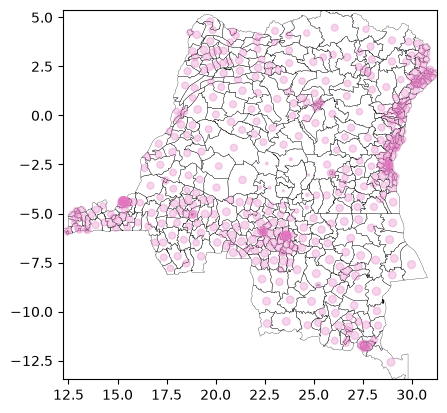

In [8]:
from math import log10

y = [e["lat"] for e in popdict.values()]
x = [e["lon"] for e in popdict.values()]
c = [log10(e["pop"] + 1.0)**2 for e in popdict.values()]
fig, ax = plot_shapes(shape_file, linewidth=0.2, alpha=1.0, edgecolor="k", facecolor="None")
ax.scatter(x, y, s=c, alpha=0.3)
ax.set_aspect(1)